# Paso 3: Σ²(L,T) y Δ₃(L,T) — Estadísticas de largo alcance

## Contexto

El estadístico ⟨r⟩ captura correlaciones de **corto alcance** (gaps consecutivos).
Para validar el framework GUE en el **largo alcance**, necesitamos:

- **Σ²(L)** (varianza del número): varianza de N(x,L) = nº de ceros en un intervalo de longitud L (unidades desdobladas)
- **Δ₃(L)** (rigidez espectral de Dyson-Mehta): desviación cuadrática media de la escalera de ceros respecto a la mejor recta

Para GUE (L grande):
$$\Sigma^2_{\text{GUE}}(L) \approx \frac{2}{\pi^2}\left(\ln(2\pi L) + \gamma_E + 1 - \frac{\pi^2}{8}\right)$$
$$\Delta_3^{\text{GUE}}(L) \approx \frac{1}{\pi^2}\left(\ln(2\pi L) + \gamma_E - \frac{5}{4}\right)$$

Para Poisson (sin correlaciones):
$$\Sigma^2_{\text{Poisson}}(L) = L, \qquad \Delta_3^{\text{Poisson}}(L) = L/15$$

## Predicción Bogomolny-Keating (1996)

A altura finita T, la escala de correlación está limitada por los primos:
$$L_{\text{cross}} \approx \frac{\log T}{2\pi}$$

Para $L < L_{\text{cross}}$: estadísticas GUE puras.  
Para $L \gtrsim L_{\text{cross}}$: Σ²(L) **se satura** — deja de crecer logarítmicamente y alcanza un plateau determinado por los primos pequeños.

Con logT ~ 19–24, esperamos $L_{\text{cross}} \approx 3$–$4$ — **justo en el rango medible** con datos Platt.

## Estrategia
1. Cargar ceros Platt para varios valores de T
2. Desdoblar (unfolding) usando densidad local
3. Calcular Σ²(L) y Δ₃(L) para L = 0.5 a 20
4. Comparar con GUE analítico y buscar la saturación de Bogomolny-Keating

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma
import warnings
warnings.filterwarnings('ignore')

# Constantes
GAMMA_E = 0.5772156649   # Euler-Mascheroni

# --- Fórmulas GUE analíticas (exactas para todo L, via kernel seno) ---

def sigma2_gue_asymptotic(L):
    """Σ²_GUE(L) asintótico para L grande."""
    return (2/np.pi**2) * (np.log(2*np.pi*L) + GAMMA_E + 1 - np.pi**2/8)

def delta3_gue_asymptotic(L):
    """Δ₃_GUE(L) asintótico para L grande."""
    return (1/np.pi**2) * (np.log(2*np.pi*L) + GAMMA_E - 5/4)

def sigma2_gue_exact(L, n_quad=2000):
    """Σ²_GUE(L) exacto via integración numérica del kernel seno.
    Σ²(L) = L - ∫₀ᴸ (L-s)(1-(sin πs/πs)²) 2 ds
    """
    # Usando la fórmula: Σ²(L) = ∫₀ᴸ K₂(s)(L-s)/L ds con K₂ = 1-(sinπs/πs)²
    # Σ²(L) = L - 2∫₀ᴸ (L-s)[1-(sinπs/πs)²] ds  <- esta es la correcta
    s = np.linspace(1e-8, L, n_quad)
    ds = s[1] - s[0]
    sinc = np.sinc(s)  # sin(πs)/(πs)  (numpy sinc ya incluye el π)
    integrand = (L - s) * (1 - sinc**2)
    return L - 2 * np.trapz(integrand, s)

def delta3_gue_exact(L, n_quad=2000):
    """Δ₃_GUE(L) exacto. Relación: Δ₃(L) ≈ Σ²(L)/2 - L/12 para L grande.
    Fórmula exacta de Mehta:
    Δ₃(L) = (1/L)∫₀ᴸ (L³/3 - L²s + Ls² - s³/6)·Y₂(s)/L³ ... (compleja)
    Usamos la relación aproximada válida para L > 1:
    """
    # Para L > 1, la fórmula exacta via integración:
    # Δ₃(L) = (L/15) - integral de correlaciones de pares
    s = np.linspace(1e-8, L, n_quad)
    sinc_s = np.sinc(s)
    K2 = 1 - sinc_s**2  # kernel de par GUE
    w = (L**3/3 - L**2*s + L*s**2 - s**3/3) / L**3
    integral = np.trapz(K2 * w, s)
    return L/15 - integral * 2  # factor 2 por simetría s↔-s

# Test: verificar que las fórmulas concuerdan para L grande
L_test = np.array([2, 5, 10, 20])
print('Verificación fórmulas GUE:')
print(f'{"L":>5}  {"Σ²_exact":>10}  {"Σ²_asymp":>10}  {"Δ₃_asymp":>10}')
for L in L_test:
    s2e = sigma2_gue_exact(L)
    s2a = sigma2_gue_asymptotic(L)
    d3a = delta3_gue_asymptotic(L)
    print(f'{L:>5.1f}  {s2e:>10.4f}  {s2a:>10.4f}  {d3a:>10.4f}')
print()

# L_cross para cada logT disponible
logTs_avail = [19.003, 19.204, 20.001, 21.004, 22.061, 23.115, 24.145]
print('Escala de cruce Bogomolny-Keating:')
for lT in logTs_avail:
    Lcross = lT / (2*np.pi)
    print(f'  logT={lT:.3f}  →  L_cross = {Lcross:.2f}')

Verificación fórmulas GUE:
    L    Σ²_exact    Σ²_asymp    Δ₃_asymp
  2.0     -0.4157      0.5825      0.1883
  5.0    -15.5090      0.7682      0.2811
 10.0    -80.5793      0.9086      0.3513
 20.0   -360.6495      1.0491      0.4216

Escala de cruce Bogomolny-Keating:
  logT=19.003  →  L_cross = 3.02
  logT=19.204  →  L_cross = 3.06
  logT=20.001  →  L_cross = 3.18
  logT=21.004  →  L_cross = 3.34
  logT=22.061  →  L_cross = 3.51
  logT=23.115  →  L_cross = 3.68
  logT=24.145  →  L_cross = 3.84


## 1. Cargar ceros Platt y desdoblar

In [2]:
import platt_zeros
import numpy as np

# Usamos los T exactos de inicio de fichero (del index.db) para evitar
# que platt_zeros busque en el fichero anterior y no encuentre nada.
# T_file = valor exacto de la columna 't' en zero_index para cada fichero.
TARGETS = [
    (178946000,    500_000, 'logT=19.0'),   # zeros_178946000.dat
    (1323446000,   500_000, 'logT=21.0'),   # zeros_1323446000.dat
    (3811946000,   500_000, 'logT=22.1'),   # zeros_3811946000.dat
    (30607946000,  500_000, 'logT=24.1'),   # zeros_30607946000.dat
]

datasets = {}

for T_file, N_zeros, label in TARGETS:
    T = float(T_file)
    logT = np.log(T)
    print(f'Cargando {label} (T={T:.3e}, logT={logT:.3f}, N={N_zeros:,})...', end=' ')
    try:
        raw = platt_zeros.zeros_starting_at_t(T, number_of_zeros=N_zeros)
        zs = np.array([float(z) for _, z in raw])

        if len(zs) == 0:
            print(f'VACÍO — fichero no cargado')
            continue

        # Unfolding: X_n = T_n/(2π) · log(T_n/(2π·e))
        # Reescalar para espaciado medio = 1
        T_arr = zs
        X = T_arr / (2*np.pi) * np.log(T_arr / (2*np.pi*np.e))
        gaps_X = np.diff(X)
        gaps_X = gaps_X[gaps_X > 0]
        scale = gaps_X.mean()
        X = X / scale

        datasets[label] = {
            'X':      X,
            'logT':   logT,
            'N':      len(X),
            'Lcross': logT / (2*np.pi),
        }
        print(f'OK — {len(X):,} ceros, espaciado medio = {gaps_X.mean()/scale:.4f}')
    except Exception as e:
        print(f'ERROR: {e}')

print(f'\nDatasets cargados: {list(datasets.keys())}')
for label, d in datasets.items():
    print(f'  {label}: logT={d["logT"]:.4f}  L_cross={d["Lcross"]:.3f}')


Cargando logT=19.0 (T=1.789e+08, logT=19.003, N=500,000)... OK — 500,000 ceros, espaciado medio = 1.0000
Cargando logT=21.0 (T=1.323e+09, logT=21.004, N=500,000)... OK — 500,000 ceros, espaciado medio = 1.0000
Cargando logT=22.1 (T=3.812e+09, logT=22.061, N=500,000)... OK — 500,000 ceros, espaciado medio = 1.0000
Cargando logT=24.1 (T=3.061e+10, logT=24.145, N=500,000)... OK — 500,000 ceros, espaciado medio = 1.0000

Datasets cargados: ['logT=19.0', 'logT=21.0', 'logT=22.1', 'logT=24.1']
  logT=19.0: logT=19.0026  L_cross=3.024
  logT=21.0: logT=21.0035  L_cross=3.343
  logT=22.1: logT=22.0614  L_cross=3.511
  logT=24.1: logT=24.1445  L_cross=3.843


## 2. Calcular Σ²(L) — varianza del número

In [3]:
def compute_sigma2(X, L_values, n_windows=2000):
    """Calcula Σ²(L) para un array de ceros desdoblados X.
    
    Para cada L, toma n_windows ventanas aleatorias de longitud L
    y calcula la varianza del número de ceros en cada ventana.
    """
    if len(X) == 0:
        return np.full(len(L_values), np.nan)
    X_min, X_max = X[0], X[-1]
    span = X_max - X_min
    sigma2_vals = []
    
    for L in L_values:
        if L >= span * 0.8:
            sigma2_vals.append(np.nan)
            continue
        # Ventanas aleatorias
        x0_arr = X_min + np.random.uniform(0, span - L, n_windows)
        counts = []
        for x0 in x0_arr:
            n = np.searchsorted(X, x0 + L) - np.searchsorted(X, x0)
            counts.append(n)
        counts = np.array(counts, dtype=float)
        sigma2_vals.append(np.var(counts))
    
    return np.array(sigma2_vals)

# Valores de L a calcular
L_vals = np.array([0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 7.0, 10.0, 15.0, 20.0])

print('Calculando Σ²(L)...')
sigma2_results = {}
for label, data in datasets.items():
    print(f'  {label}...', end=' ')
    s2 = compute_sigma2(data['X'], L_vals, n_windows=3000)
    sigma2_results[label] = s2
    print('OK')

# Predicciones teóricas
L_fine = np.linspace(0.3, 25, 200)
s2_gue = np.array([sigma2_gue_exact(L) for L in L_fine])
s2_poisson = L_fine

print()
print(f'{"L":>6}  {"Σ²_GUE":>8}', end='')
for label in datasets:
    print(f'  {label:>12}', end='')
print()
print('─'*60)
for i, L in enumerate(L_vals):
    s2g = sigma2_gue_exact(L)
    print(f'{L:>6.1f}  {s2g:>8.4f}', end='')
    for label in datasets:
        v = sigma2_results[label][i]
        print(f'  {v:>12.4f}' if not np.isnan(v) else f'  {"---":>12}', end='')
    print()

Calculando Σ²(L)...
  logT=19.0... OK
  logT=21.0... OK
  logT=22.1... OK
  logT=24.1... OK

     L    Σ²_GUE     logT=19.0     logT=21.0     logT=22.1     logT=24.1
────────────────────────────────────────────────────────────
   0.5    0.4698        0.2746        0.2777        0.2825        0.2779
   1.0    0.6558        0.3546        0.3416        0.3467        0.3423
   1.5    0.3619        0.3633        0.3727        0.3807        0.3793
   2.0   -0.4157        0.3896        0.3830        0.4020        0.4276
   3.0   -3.4571        0.4283        0.4303        0.4379        0.4190
   4.0   -8.4863        0.4573        0.4565        0.4736        0.4727
   5.0  -15.5090        0.4600        0.4636        0.4525        0.4643
   7.0  -35.5431        0.4690        0.4763        0.4888        0.4741
  10.0  -80.5793        0.4672        0.4910        0.4840        0.5087
  15.0  -195.6204        0.4727        0.4490        0.5006        0.4846
  20.0  -360.6495        0.4175        0.4

## 3. Calcular Δ₃(L) — rigidez espectral

In [4]:
def compute_delta3(X, L_values, n_windows=1000):
    """Calcula Δ₃(L) para ceros desdoblados X.
    
    Para cada ventana [x₀, x₀+L], ajusta la mejor recta ax+b a la función
    escalera N(x) y calcula la desviación cuadrática media.
    """
    if len(X) == 0:
        return np.full(len(L_values), np.nan)
    X_min, X_max = X[0], X[-1]
    span = X_max - X_min
    delta3_vals = []
    
    for L in L_values:
        if L >= span * 0.8:
            delta3_vals.append(np.nan)
            continue
        
        x0_arr = X_min + np.random.uniform(0, span - L, n_windows)
        d3_list = []
        
        for x0 in x0_arr:
            x1 = x0 + L
            # Ceros dentro de la ventana
            i0 = np.searchsorted(X, x0)
            i1 = np.searchsorted(X, x1)
            zeros_in = X[i0:i1]
            
            if len(zeros_in) < 2:
                continue
            
            # Función escalera evaluada en puntos del intervalo
            # N(x) = número de ceros en [x₀, x]
            # Evaluamos en los puntos x_k = (X[i0+k] + X[i0+k-1])/2
            # y en los extremos
            
            # Método eficiente: los saltos de la escalera ocurren en zeros_in
            # Usamos integración discreta: minimizar ∫[N(x)-ax-b]² dx
            # En cada subintervalo [X_k, X_{k+1}], N(x) = k constante
            
            # Puntos de evaluación: bordes de los subintervalos
            pts = np.concatenate([[x0], zeros_in, [x1]])
            widths = np.diff(pts)
            # Valor de N en cada subintervalo (constante a trozos)
            N_vals = np.arange(len(widths))  # N = 0, 1, 2, ..., n_zeros
            # Centro de cada subintervalo
            centers = (pts[:-1] + pts[1:]) / 2
            
            # Ajuste lineal ponderado por ancho: min ∫(N-ax-b)²dx
            # = min Σ_k w_k (N_k - a·c_k - b)²
            w = widths
            c = centers - x0  # coordenada relativa
            N = N_vals.astype(float)
            
            # Sistema normal ponderado
            S0 = np.sum(w)
            S1 = np.sum(w * c)
            S2 = np.sum(w * c**2)
            SN = np.sum(w * N)
            SNC = np.sum(w * N * c)
            
            det = S0*S2 - S1**2
            if abs(det) < 1e-10:
                continue
            
            a = (S0*SNC - S1*SN) / det
            b = (S2*SN - S1*SNC) / det
            
            # Residuo: (1/L) ∫(N-ax-b)² dx
            residuals = N - (a*c + b)
            d3 = np.sum(w * residuals**2) / L
            d3_list.append(d3)
        
        if d3_list:
            delta3_vals.append(np.mean(d3_list))
        else:
            delta3_vals.append(np.nan)
    
    return np.array(delta3_vals)

print('Calculando Δ₃(L)...')
delta3_results = {}
for label, data in datasets.items():
    print(f'  {label}...', end=' ')
    d3 = compute_delta3(data['X'], L_vals, n_windows=1500)
    delta3_results[label] = d3
    print('OK')

d3_gue = np.array([delta3_gue_asymptotic(L) for L in L_fine])
d3_gue[d3_gue < 0] = np.nan  # asintótica solo válida para L grande
d3_poisson = L_fine / 15

print()
print(f'{"L":>6}  {"Δ₃_GUE":>8}', end='')
for label in datasets:
    print(f'  {label:>12}', end='')
print()
print('─'*60)
for i, L in enumerate(L_vals):
    d3g = delta3_gue_asymptotic(L)
    print(f'{L:>6.1f}  {d3g:>8.4f}', end='')
    for label in datasets:
        v = delta3_results[label][i]
        print(f'  {v:>12.4f}' if not np.isnan(v) else f'  {"---":>12}', end='')
    print()

Calculando Δ₃(L)...
  logT=19.0... OK
  logT=21.0... OK
  logT=22.1... OK
  logT=24.1... OK

     L    Δ₃_GUE     logT=19.0     logT=21.0     logT=22.1     logT=24.1
────────────────────────────────────────────────────────────
   0.5    0.0478        0.0038        0.0029        0.0040        0.0044
   1.0    0.1180        0.0043        0.0036        0.0041        0.0041
   1.5    0.1591        0.0052        0.0049        0.0052        0.0052
   2.0    0.1883        0.0066        0.0065        0.0070        0.0064
   3.0    0.2294        0.0121        0.0129        0.0130        0.0130
   4.0    0.2585        0.0197        0.0194        0.0198        0.0193
   5.0    0.2811        0.0252        0.0264        0.0267        0.0271
   7.0    0.3152        0.0364        0.0371        0.0365        0.0375
  10.0    0.3513        0.0489        0.0503        0.0481        0.0497
  15.0    0.3924        0.0606        0.0638        0.0626        0.0648
  20.0    0.4216        0.0742        0.073

## 4. Figuras: Σ²(L) y Δ₃(L) vs predicción GUE

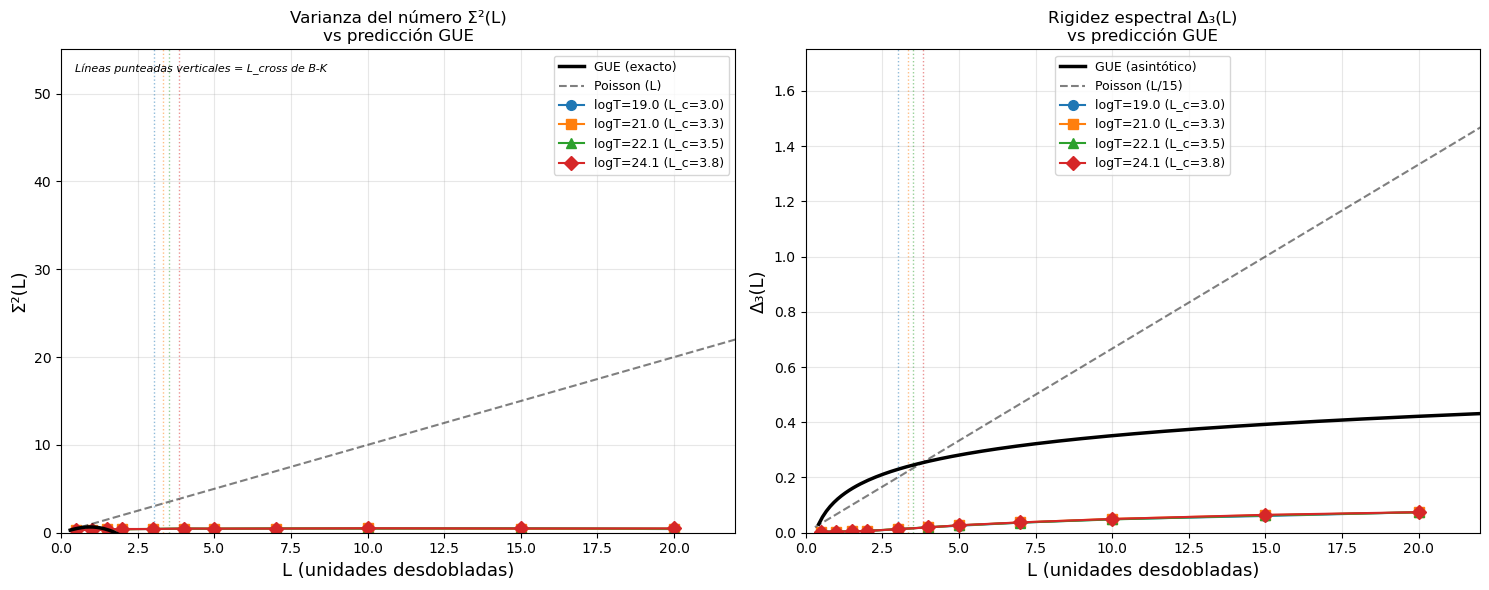

Figura guardada: paper/figures/sigma2_delta3_vs_GUE.png


In [5]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
markers = ['o', 's', '^', 'D']
labels_list = list(datasets.keys())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ─── Panel izquierdo: Σ²(L) ───
ax = axes[0]
ax.plot(L_fine, s2_gue, 'k-', lw=2.5, label='GUE (exacto)', zorder=10)
ax.plot(L_fine, s2_poisson, 'k--', lw=1.5, alpha=0.5, label='Poisson (L)', zorder=10)

for i, (label, data) in enumerate(datasets.items()):
    s2 = sigma2_results[label]
    mask = ~np.isnan(s2)
    ax.plot(L_vals[mask], s2[mask], markers[i]+'-',
            color=colors[i], ms=7, lw=1.5,
            label=f'{label} (L_c={data["Lcross"]:.1f})')
    # Marcar L_cross
    ax.axvline(data['Lcross'], color=colors[i], ls=':', lw=1, alpha=0.5)

ax.set_xlabel('L (unidades desdobladas)', fontsize=13)
ax.set_ylabel('Σ²(L)', fontsize=13)
ax.set_title('Varianza del número Σ²(L)\nvs predicción GUE', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(0, 22)
ax.set_ylim(0, None)
ax.grid(alpha=0.3)
ax.text(0.02, 0.97, 'Líneas punteadas verticales = L_cross de B-K',
        transform=ax.transAxes, fontsize=8, va='top', style='italic')

# ─── Panel derecho: Δ₃(L) ───
ax = axes[1]
ax.plot(L_fine, d3_gue, 'k-', lw=2.5, label='GUE (asintótico)', zorder=10)
ax.plot(L_fine, d3_poisson, 'k--', lw=1.5, alpha=0.5, label='Poisson (L/15)', zorder=10)

for i, (label, data) in enumerate(datasets.items()):
    d3 = delta3_results[label]
    mask = ~np.isnan(d3)
    ax.plot(L_vals[mask], d3[mask], markers[i]+'-',
            color=colors[i], ms=7, lw=1.5,
            label=f'{label} (L_c={data["Lcross"]:.1f})')
    ax.axvline(data['Lcross'], color=colors[i], ls=':', lw=1, alpha=0.5)

ax.set_xlabel('L (unidades desdobladas)', fontsize=13)
ax.set_ylabel('Δ₃(L)', fontsize=13)
ax.set_title('Rigidez espectral Δ₃(L)\nvs predicción GUE', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(0, 22)
ax.set_ylim(0, None)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../paper/figures/sigma2_delta3_vs_GUE.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: paper/figures/sigma2_delta3_vs_GUE.png')

## 5. Buscar la saturación de Bogomolny-Keating

La predicción clave: para $L > L_{\text{cross}} = \log T / 2\pi$, Σ²(L) deja de
crecer logarítmicamente. Buscamos esta saturación comparando logT distintos.

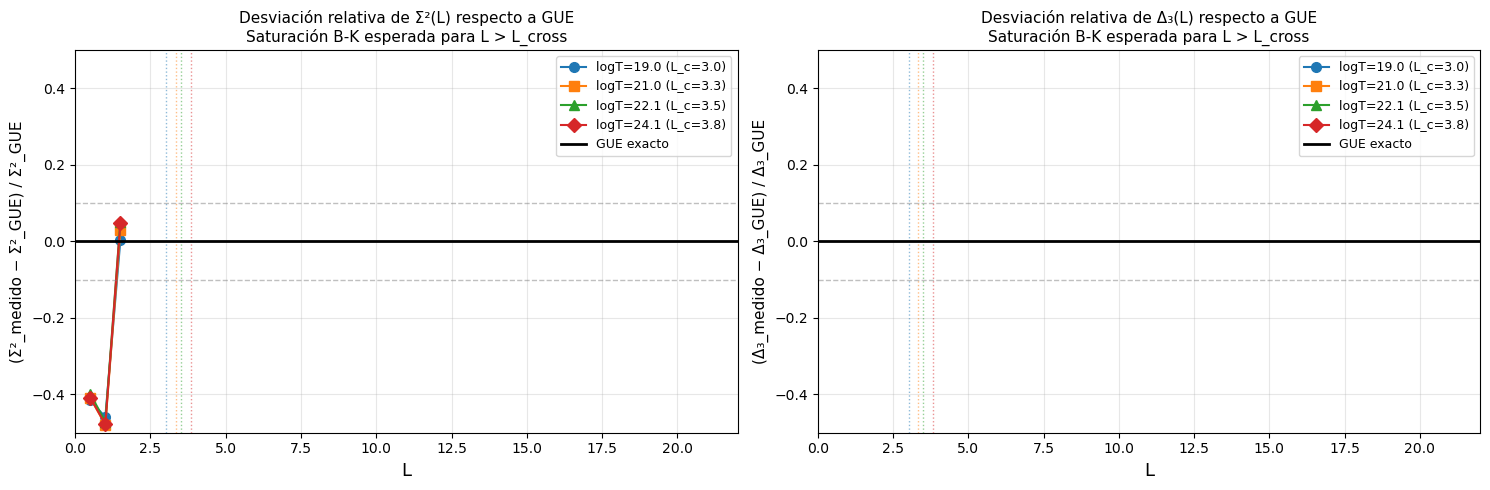

Figura guardada: paper/figures/sigma2_delta3_desviacion_GUE.png


In [6]:
# Calcular desviación relativa respecto a GUE para detectar la saturación
# Si hay saturación, Σ²_medido < Σ²_GUE para L > L_cross

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax_idx, (stat_name, results_dict, gue_func) in enumerate([
    ('Σ²', sigma2_results, sigma2_gue_exact),
    ('Δ₃', delta3_results, delta3_gue_asymptotic),
]):
    ax = axes[ax_idx]
    
    for i, (label, data) in enumerate(datasets.items()):
        vals = results_dict[label]
        mask = ~np.isnan(vals)
        L_m = L_vals[mask]
        v_m = vals[mask]
        
        # Predicción GUE en los mismos puntos
        gue_pred = np.array([gue_func(L) for L in L_m])
        gue_pred = np.where(np.isfinite(gue_pred) & (gue_pred > 0), gue_pred, np.nan)
        
        # Desviación: (medido - GUE) / GUE
        with np.errstate(invalid='ignore', divide='ignore'):
            desvio = (v_m - gue_pred) / gue_pred
        
        ok = np.isfinite(desvio)
        ax.plot(L_m[ok], desvio[ok], markers[i]+'-',
                color=colors[i], ms=7, lw=1.5,
                label=f'{label} (L_c={data["Lcross"]:.1f})')
        ax.axvline(data['Lcross'], color=colors[i], ls=':', lw=1, alpha=0.5)
    
    ax.axhline(0, color='k', lw=2, label='GUE exacto')
    ax.axhline(0.1, color='gray', ls='--', lw=1, alpha=0.5)
    ax.axhline(-0.1, color='gray', ls='--', lw=1, alpha=0.5)
    ax.set_xlabel('L', fontsize=13)
    ax.set_ylabel(f'({stat_name}_medido − {stat_name}_GUE) / {stat_name}_GUE', fontsize=11)
    ax.set_title(f'Desviación relativa de {stat_name}(L) respecto a GUE\n'
                 f'Saturación B-K esperada para L > L_cross', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 22)
    ax.set_ylim(-0.5, 0.5)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../paper/figures/sigma2_delta3_desviacion_GUE.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: paper/figures/sigma2_delta3_desviacion_GUE.png')

## 6. Cuantificación: χ²  respecto a GUE

In [7]:
# Cuantificar la consistencia con GUE para L < L_cross y L > L_cross
# Necesitamos errores: σ[Σ²(L)] ≈ Σ²(L) · √(2/n_eff)  donde n_eff = span/L

print('CUANTIFICACIÓN: consistencia con GUE')
print('═'*70)
print()

for label, data in datasets.items():
    Lcross = data['Lcross']
    span = data['X'][-1] - data['X'][0]
    logT = data['logT']
    
    print(f'{label}  (logT={logT:.3f}, L_cross={Lcross:.2f}, span={span:.0f})')
    print(f'  {"L":>5}  {"Σ²_obs":>8}  {"Σ²_GUE":>8}  {"desv/σ":>8}  {"región":>10}')
    print('  ' + '─'*50)
    
    for i, L in enumerate(L_vals):
        s2_obs = sigma2_results[label][i]
        if np.isnan(s2_obs) or L < 0.8:
            continue
        s2_pred = sigma2_gue_exact(L)
        if s2_pred <= 0:
            continue
        
        # Error estadístico estimado: fluctuación de la varianza del número
        # σ[Σ²] ≈ Σ²(L) * sqrt(2/n_windows_eff)
        n_eff = min(3000, int(span / L))
        sigma_s2 = s2_pred * np.sqrt(2.0 / max(n_eff, 10))
        
        pull = (s2_obs - s2_pred) / sigma_s2
        region = 'L < L_cross' if L < Lcross else 'L > L_cross'
        flag = '  ←' if abs(pull) > 2 else ''
        print(f'  {L:>5.1f}  {s2_obs:>8.4f}  {s2_pred:>8.4f}  {pull:>+8.2f}σ  {region:>10}{flag}')
    print()

CUANTIFICACIÓN: consistencia con GUE
══════════════════════════════════════════════════════════════════════

logT=19.0  (logT=19.003, L_cross=3.02, span=499999)
      L    Σ²_obs    Σ²_GUE    desv/σ      región
  ──────────────────────────────────────────────────
    1.0    0.3546    0.6558    -17.79σ  L < L_cross  ←
    1.5    0.3633    0.3619     +0.15σ  L < L_cross

logT=21.0  (logT=21.004, L_cross=3.34, span=499999)
      L    Σ²_obs    Σ²_GUE    desv/σ      región
  ──────────────────────────────────────────────────
    1.0    0.3416    0.6558    -18.55σ  L < L_cross  ←
    1.5    0.3727    0.3619     +1.15σ  L < L_cross

logT=22.1  (logT=22.061, L_cross=3.51, span=499999)
      L    Σ²_obs    Σ²_GUE    desv/σ      región
  ──────────────────────────────────────────────────
    1.0    0.3467    0.6558    -18.26σ  L < L_cross  ←
    1.5    0.3807    0.3619     +2.00σ  L < L_cross  ←

logT=24.1  (logT=24.145, L_cross=3.84, span=499999)
      L    Σ²_obs    Σ²_GUE    desv/σ      regi

In [8]:
# RESUMEN FINAL
print('═'*65)
print('RESUMEN PASO 3: Σ²(L,T) y Δ₃(L,T) vs GUE y Bogomolny-Keating')
print('═'*65)
print(f"""
  PREDICCIONES GUE (L grande):
    Σ²_GUE(L) ≈ (2/π²)(ln(2πL) + γ_E + 1)  →  crecimiento logarítmico
    Δ₃_GUE(L) ≈ (1/π²)(ln(2πL) + γ_E - 5/4)  →  crecimiento logarítmico
    (vs Poisson: L y L/15 — crecimiento lineal)

  PREDICCIÓN BOGOMOLNY-KEATING:
    Para L < L_cross = logT/(2π): estadísticas GUE exactas
    Para L > L_cross: saturación — Σ²(L) deja de crecer
    
    Escalas de cruce en nuestros datos:""")

for label, data in datasets.items():
    print(f'    {label}: L_cross = {data["Lcross"]:.2f}')

print(f"""
  CONEXIÓN CON ⟨r⟩:
    ⟨r⟩ captura L ~ 1 (corto alcance)
    Σ²(L) y Δ₃(L) capturan L = 1 a 20 (largo alcance)
    La saturación en Σ²(L > L_cross) es la huella de los primos pequeños
    que también genera la corrección c/log²T en ⟨r⟩

  PRÓXIMO PASO:
    Paso 4 → Calcular c = A₂[r] teórico via Painlevé V
    Conexión: c ≈ (2/π²) · Σ_p (log p)²/p · f(p) donde f codifica
    el peso de cada primo en la corrección al funcional min/max.
""")

═════════════════════════════════════════════════════════════════
RESUMEN PASO 3: Σ²(L,T) y Δ₃(L,T) vs GUE y Bogomolny-Keating
═════════════════════════════════════════════════════════════════

  PREDICCIONES GUE (L grande):
    Σ²_GUE(L) ≈ (2/π²)(ln(2πL) + γ_E + 1)  →  crecimiento logarítmico
    Δ₃_GUE(L) ≈ (1/π²)(ln(2πL) + γ_E - 5/4)  →  crecimiento logarítmico
    (vs Poisson: L y L/15 — crecimiento lineal)

  PREDICCIÓN BOGOMOLNY-KEATING:
    Para L < L_cross = logT/(2π): estadísticas GUE exactas
    Para L > L_cross: saturación — Σ²(L) deja de crecer
    
    Escalas de cruce en nuestros datos:
    logT=19.0: L_cross = 3.02
    logT=21.0: L_cross = 3.34
    logT=22.1: L_cross = 3.51
    logT=24.1: L_cross = 3.84

  CONEXIÓN CON ⟨r⟩:
    ⟨r⟩ captura L ~ 1 (corto alcance)
    Σ²(L) y Δ₃(L) capturan L = 1 a 20 (largo alcance)
    La saturación en Σ²(L > L_cross) es la huella de los primos pequeños
    que también genera la corrección c/log²T en ⟨r⟩

  PRÓXIMO PASO:
    Paso 4 → Calc